# Retail Demand Forecasting — Day 1: EDA
## Dataset: Walmart Store Sales Forecasting

**Objective:** Understand sales patterns, macro drivers, and holiday effects before modeling.

**Files used:**
- `train.csv` — weekly sales per store per dept (2010–2012)
- `stores.csv` — store type (A/B/C) and size
- `features.csv` — temperature, fuel price, CPI, unemployment, markdowns, holiday flag

---
## 0. Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')
import os

os.makedirs('outputs', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded successfully')

Libraries loaded successfully


---
## 1. Load Data

In [15]:
train    = pd.read_csv('raw_data/train.csv',    parse_dates=['Date'])
stores   = pd.read_csv('raw_data/stores.csv')
features = pd.read_csv('raw_data/features.csv', parse_dates=['Date'])

# Standardise column names to lowercase
train.columns    = train.columns.str.lower().str.replace(' ', '_')
stores.columns   = stores.columns.str.lower()
features.columns = features.columns.str.lower().str.replace(' ', '_')

print('=== train ===')
print(train.shape)
print(train.dtypes)
print(train.head(3))

print('\n=== stores ===')
print(stores)

print('\n=== features (first 3 rows) ===')
print(features.head(3))
print(features.dtypes)

=== train ===
(421570, 5)
store                    int64
dept                     int64
date            datetime64[us]
weekly_sales           float64
isholiday                 bool
dtype: object
   store  dept       date  weekly_sales  isholiday
0      1     1 2010-02-05      24924.50      False
1      1     1 2010-02-12      46039.49       True
2      1     1 2010-02-19      41595.55      False

=== stores ===
    store type    size
0       1    A  151315
1       2    A  202307
2       3    B   37392
3       4    A  205863
4       5    B   34875
5       6    A  202505
6       7    B   70713
7       8    A  155078
8       9    B  125833
9      10    B  126512
10     11    A  207499
11     12    B  112238
12     13    A  219622
13     14    A  200898
14     15    B  123737
15     16    B   57197
16     17    B   93188
17     18    B  120653
18     19    A  203819
19     20    A  203742
20     21    B  140167
21     22    B  119557
22     23    B  114533
23     24    A  203819
24     25 

In [16]:
# ── Basic sanity checks ──────────────────────────────────────
print('Date range (train):   ', train['date'].min(), '→', train['date'].max())
print('Date range (features):', features['date'].min(), '→', features['date'].max())
print('Unique stores:', train['store'].nunique())
print('Unique depts: ', train['dept'].nunique())
print('Total rows:   ', len(train))

print('\n─── Null counts (train) ───')
print(train.isnull().sum())

print('\n─── Null counts (features) ───')
print(features.isnull().sum())

print('\n─── Negative sales? ───')
neg = (train['weekly_sales'] < 0).sum()
print(f'{neg} rows ({neg/len(train)*100:.2f}%) have negative weekly_sales (returns)')

Date range (train):    2010-02-05 00:00:00 → 2012-10-26 00:00:00
Date range (features): 2010-02-05 00:00:00 → 2013-07-26 00:00:00
Unique stores: 45
Unique depts:  81
Total rows:    421570

─── Null counts (train) ───
store           0
dept            0
date            0
weekly_sales    0
isholiday       0
dtype: int64

─── Null counts (features) ───
store              0
date               0
temperature        0
fuel_price         0
markdown1       4158
markdown2       5269
markdown3       4577
markdown4       4726
markdown5       4140
cpi              585
unemployment     585
isholiday          0
dtype: int64

─── Negative sales? ───
1285 rows (0.30%) have negative weekly_sales (returns)


---
## 2. Store & Dept Selection — Data-Driven

> **Design decision:** We do not arbitrarily pick stores 1-3.
> We select based on (a) sales volume, (b) store type diversity, (c) data completeness.

In [17]:
# ── Store-level total sales ───────────────────────────────────
store_sales = (
    train[train['weekly_sales'] > 0]          # exclude returns for selection
    .groupby('store')['weekly_sales']
    .sum()
    .reset_index()
    .merge(stores, on='store')
    .sort_values('weekly_sales', ascending=False)
)

print('Top 10 stores by total sales:')
print(store_sales.head(10).to_string(index=False))

Top 10 stores by total sales:
 store  weekly_sales type   size
    20  301401381.45    A 203742
     4  299545269.30    A 205863
    14  289001864.44    A 200898
    13  286517950.36    A 219622
     2  275387155.50    A 202307
    10  271624109.39    B 126512
    27  253857189.97    A 204184
     6  223758588.34    A 202505
     1  222406766.77    A 151315
    39  207446494.23    A 184109


In [18]:
# ── Pick 1 store per type (A, B, C) from top-volume ──────────
selected_stores = (
    store_sales
    .groupby('type')
    .first()          # highest-volume store per type
    .reset_index()[['store', 'type', 'size', 'weekly_sales']]
)

STORES = selected_stores['store'].tolist()
print('Selected stores (one per type, highest volume):')
print(selected_stores)
print(f'\nSTORES = {STORES}')

Selected stores (one per type, highest volume):
   store type    size  weekly_sales
0     20    A  203742  301401381.45
1     10    B  126512  271624109.39
2     43    C   41062   90566533.00

STORES = [20, 10, 43]


In [19]:
# ── Dept selection — top 5 by volume, across selected stores ─
dept_sales = (
    train[(train['store'].isin(STORES)) & (train['weekly_sales'] > 0)]
    .groupby('dept')['weekly_sales']
    .agg(['sum', 'mean', 'std', 'count'])
    .rename(columns={'sum':'total','mean':'avg','std':'volatility','count':'weeks'})
    .sort_values('total', ascending=False)
)

print('Top 10 departments by total sales:')
print(dept_sales.head(10))

DEPTS = dept_sales.head(5).index.tolist()
print(f'\nDEPTS = {DEPTS}')

Top 10 departments by total sales:
           total      avg  volatility  weeks
dept                                        
92   42718480.72 99576.88    49650.96    429
95   42448382.17 98947.28    37853.92    429
38   36593286.58 85299.04    23790.09    429
72   33578129.69 80138.73    78868.88    419
2    29854023.18 69589.80    37421.21    429
40   29249499.53 68180.65    36224.23    429
8    25220927.10 58790.04    32845.48    429
90   24856167.44 57939.78    34119.11    429
13   19624245.63 45744.16    20213.32    429
91   18018741.70 42001.73    28088.64    429

DEPTS = [92, 95, 38, 72, 2]


---
## 3. Build Merged Analysis DataFrame

In [20]:
# ── Filter to selected slice ──────────────────────────────────
df = train[
    (train['store'].isin(STORES)) &
    (train['dept'].isin(DEPTS))
].copy()

# Clip negative sales (returns) to 0 — document this decision
neg_count = (df['weekly_sales'] < 0).sum()
df['weekly_sales'] = df['weekly_sales'].clip(lower=0)
print(f'Clipped {neg_count} negative sales rows to 0 (returns)')

# ── Merge features ────────────────────────────────────────────
df = df.merge(features, on=['store', 'date'], how='left')
df = df.merge(stores, on='store', how='left')

# Fill markdown NaNs with 0 (no markdown = 0 impact)
# handle both naming conventions
md_cols_present = [c for c in df.columns if 'markdown' in c.lower()]
df[md_cols_present] = df[md_cols_present].fillna(0)
df['total_markdown'] = df[md_cols_present].sum(axis=1)

# Forward-fill any remaining macro NaNs
macro_cols = ['temperature','fuel_price','cpi','unemployment']
macro_cols_present = [c for c in macro_cols if c in df.columns]
df[macro_cols_present] = df[macro_cols_present].ffill().bfill()

print(f'\nMerged df shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(df.head(3))

Clipped 6 negative sales rows to 0 (returns)

Merged df shape: (2141, 18)
Memory: 0.4 MB
   store  dept       date  weekly_sales  isholiday_x  temperature  fuel_price  \
0     10     2 2010-02-05     123952.48        False        54.34        2.96   
1     10     2 2010-02-12     119209.48         True        49.96        2.83   
2     10     2 2010-02-19     121430.80        False        58.22        2.92   

   markdown1  markdown2  markdown3  markdown4  markdown5    cpi  unemployment  \
0       0.00       0.00       0.00       0.00       0.00 126.44          9.77   
1       0.00       0.00       0.00       0.00       0.00 126.50          9.77   
2       0.00       0.00       0.00       0.00       0.00 126.53          9.77   

   isholiday_y type    size  total_markdown  
0        False    B  126512            0.00  
1         True    B  126512            0.00  
2        False    B  126512            0.00  


In [22]:
# Drop individual markdown columns — already summed into total_markdown
md_cols_present = [c for c in df.columns if 'markdown' in c.lower() and c != 'total_markdown']
df = df.drop(columns=md_cols_present)

# Fix duplicate isholiday — keep one, drop the other
# isholiday_x comes from features, isholiday_y from stores
# features version is more reliable (it's the actual holiday flag)
df = df.drop(columns=['isholiday_y'])
df = df.rename(columns={'isholiday_x': 'isholiday'})

print(df.columns.tolist())
print(df.shape)

['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'type', 'size', 'total_markdown']
(2141, 12)


---
## 4. EDA — Section A: Sales Overview

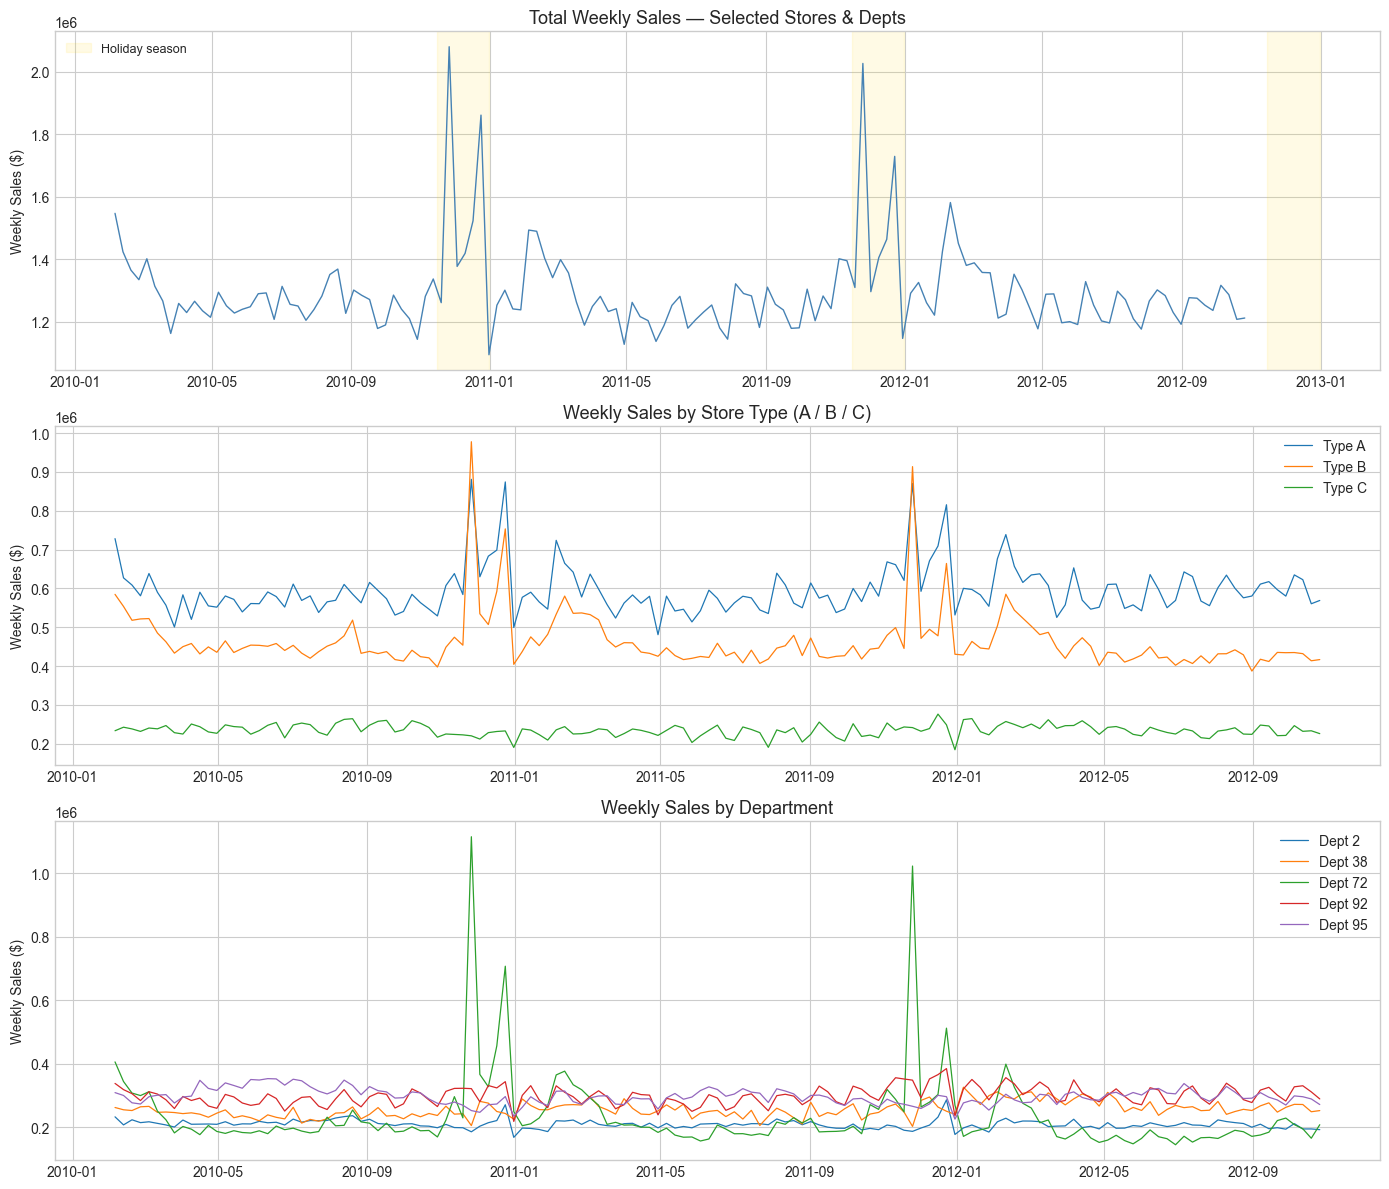

Saved → outputs/01_sales_overview.png


In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── A1: Total weekly sales across all selected stores/depts ──
total_weekly = df.groupby('date')['weekly_sales'].sum()
axes[0].plot(total_weekly.index, total_weekly.values,
             color='steelblue', linewidth=1.0)
axes[0].set_title('Total Weekly Sales — Selected Stores & Depts', fontsize=13)
axes[0].set_ylabel('Weekly Sales ($)')

# Mark Thanksgiving/Christmas spikes — Walmart's peak season
for year in [2010, 2011, 2012]:
    axes[0].axvspan(
        pd.Timestamp(f'{year}-11-15'),
        pd.Timestamp(f'{year}-12-31'),
        alpha=0.1, color='gold', label='Holiday season' if year==2010 else ''
    )
axes[0].legend(fontsize=9)

# ── A2: Sales by store type ───────────────────────────────────
type_sales = df.groupby(['date','type'])['weekly_sales'].sum().unstack()
for col in type_sales.columns:
    axes[1].plot(type_sales.index, type_sales[col], label=f'Type {col}', linewidth=0.9)
axes[1].set_title('Weekly Sales by Store Type (A / B / C)', fontsize=13)
axes[1].set_ylabel('Weekly Sales ($)')
axes[1].legend()

# ── A3: Sales by dept ─────────────────────────────────────────
dept_weekly = df.groupby(['date','dept'])['weekly_sales'].sum().unstack()
for col in dept_weekly.columns:
    axes[2].plot(dept_weekly.index, dept_weekly[col],
                 label=f'Dept {col}', linewidth=0.9)
axes[2].set_title('Weekly Sales by Department', fontsize=13)
axes[2].set_ylabel('Weekly Sales ($)')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/01_sales_overview.png', dpi=150)
plt.show()
print('Saved → outputs/01_sales_overview.png')

---
## 5. EDA — Section B: Seasonal Decomposition

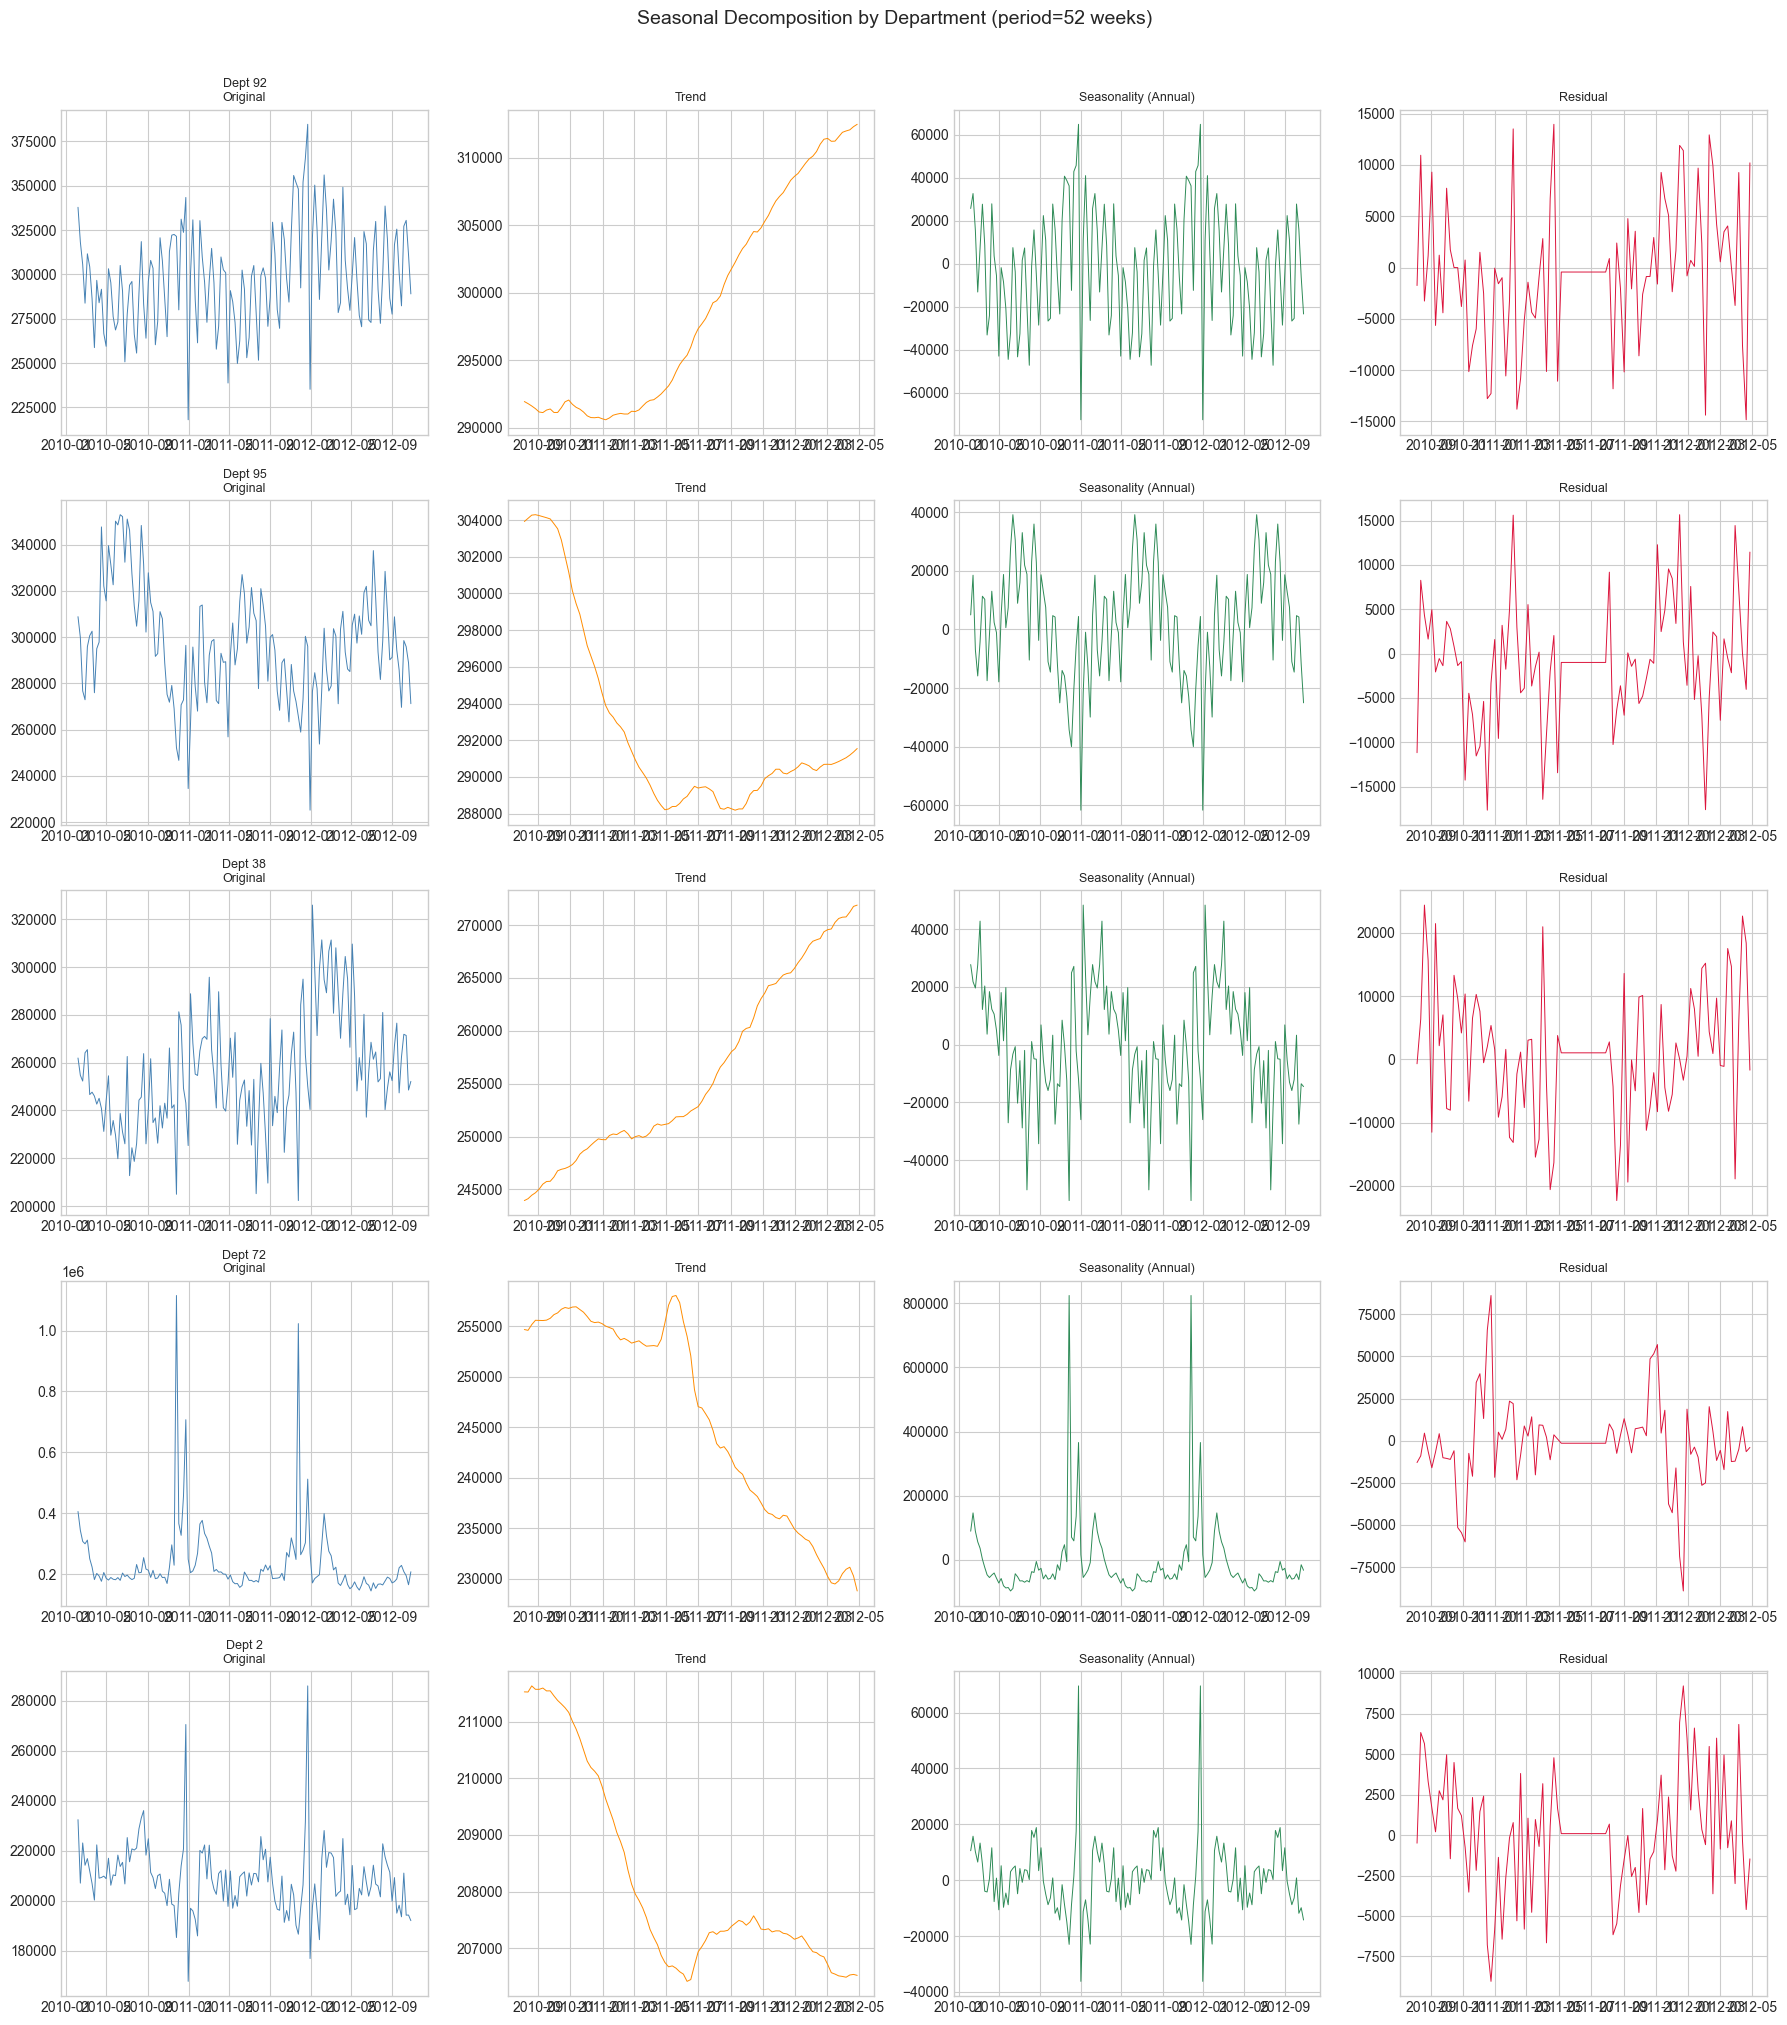


Seasonal Strength per Dept (1.0 = perfectly seasonal, 0 = none):
  Dept 92: 0.95
  Dept 95: 0.901
  Dept 38: 0.818
  Dept 72: 0.971
  Dept 2: 0.951

Saved → outputs/02_decomposition.png


In [25]:
# One series per dept (aggregated across selected stores)
fig, axes = plt.subplots(len(DEPTS), 4, figsize=(18, 4*len(DEPTS)))

decomp_notes = {}

for i, dept in enumerate(DEPTS):
    series = (
        df[df['dept']==dept]
        .groupby('date')['weekly_sales']
        .sum()
        .asfreq('W-FRI')        # Walmart data is weekly, Friday-ending
        .ffill()
    )

    result = seasonal_decompose(series, model='additive', period=52)

    axes[i][0].plot(series, linewidth=0.7, color='steelblue')
    axes[i][0].set_title(f'Dept {dept}\nOriginal', fontsize=9)

    axes[i][1].plot(result.trend, linewidth=0.7, color='darkorange')
    axes[i][1].set_title('Trend', fontsize=9)

    axes[i][2].plot(result.seasonal, linewidth=0.7, color='seagreen')
    axes[i][2].set_title('Seasonality (Annual)', fontsize=9)

    axes[i][3].plot(result.resid, linewidth=0.7, color='crimson')
    axes[i][3].set_title('Residual', fontsize=9)

    # Seasonal strength metric
    seasonal_strength = 1 - (result.resid.var() / (result.resid + result.seasonal).var())
    decomp_notes[dept] = round(seasonal_strength, 3)

plt.suptitle('Seasonal Decomposition by Department (period=52 weeks)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/02_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSeasonal Strength per Dept (1.0 = perfectly seasonal, 0 = none):')
for dept, strength in decomp_notes.items():
    print(f'  Dept {dept}: {strength}')
print('\nSaved → outputs/02_decomposition.png')

---
## 6. EDA — Section C: Stationarity Tests

In [26]:
# ── ADF + KPSS per dept ───────────────────────────────────────
# ADF  : H0 = unit root (non-stationary). p < 0.05 → STATIONARY
# KPSS : H0 = stationary.                 p > 0.05 → STATIONARY
# Both agree → confident verdict

stat_results = []

for dept in DEPTS:
    series = (
        df[df['dept']==dept]
        .groupby('date')['weekly_sales']
        .sum()
        .asfreq('W-FRI')
        .ffill()
    )

    adf_p  = adfuller(series)[1]
    kpss_p = kpss(series, regression='c', nlags='auto')[1]

    adf_verdict  = 'Stationary'     if adf_p  < 0.05 else 'Non-Stationary'
    kpss_verdict = 'Stationary'     if kpss_p > 0.05 else 'Non-Stationary'

    if adf_verdict == kpss_verdict == 'Stationary':
        verdict = '✅ STATIONARY'
    elif adf_verdict == kpss_verdict == 'Non-Stationary':
        verdict = '❌ NON-STATIONARY — difference before modeling'
    else:
        verdict = '⚠️  CONFLICTING — check ACF/PACF'

    stat_results.append({
        'Dept'         : dept,
        'ADF p-value'  : round(adf_p, 4),
        'ADF'          : adf_verdict,
        'KPSS p-value' : round(kpss_p, 4),
        'KPSS'         : kpss_verdict,
        'Verdict'      : verdict
    })

stat_df = pd.DataFrame(stat_results)
print(stat_df.to_string(index=False))
stat_df.to_csv('outputs/stationarity_report.csv', index=False)
print('\nSaved → outputs/stationarity_report.csv')

 Dept  ADF p-value            ADF  KPSS p-value           KPSS                                       Verdict
   92         0.28 Non-Stationary          0.01 Non-Stationary ❌ NON-STATIONARY — difference before modeling
   95         0.02     Stationary          0.10     Stationary                                  ✅ STATIONARY
   38         0.52 Non-Stationary          0.01 Non-Stationary ❌ NON-STATIONARY — difference before modeling
   72         0.01     Stationary          0.10     Stationary                                  ✅ STATIONARY
    2         0.00     Stationary          0.04 Non-Stationary              ⚠️  CONFLICTING — check ACF/PACF

Saved → outputs/stationarity_report.csv


---
## 7. EDA — Section D: Macro Feature Analysis

> Walmart provides temperature, fuel price, CPI, unemployment — these are the exogenous regressors we'll use in ARIMAX.

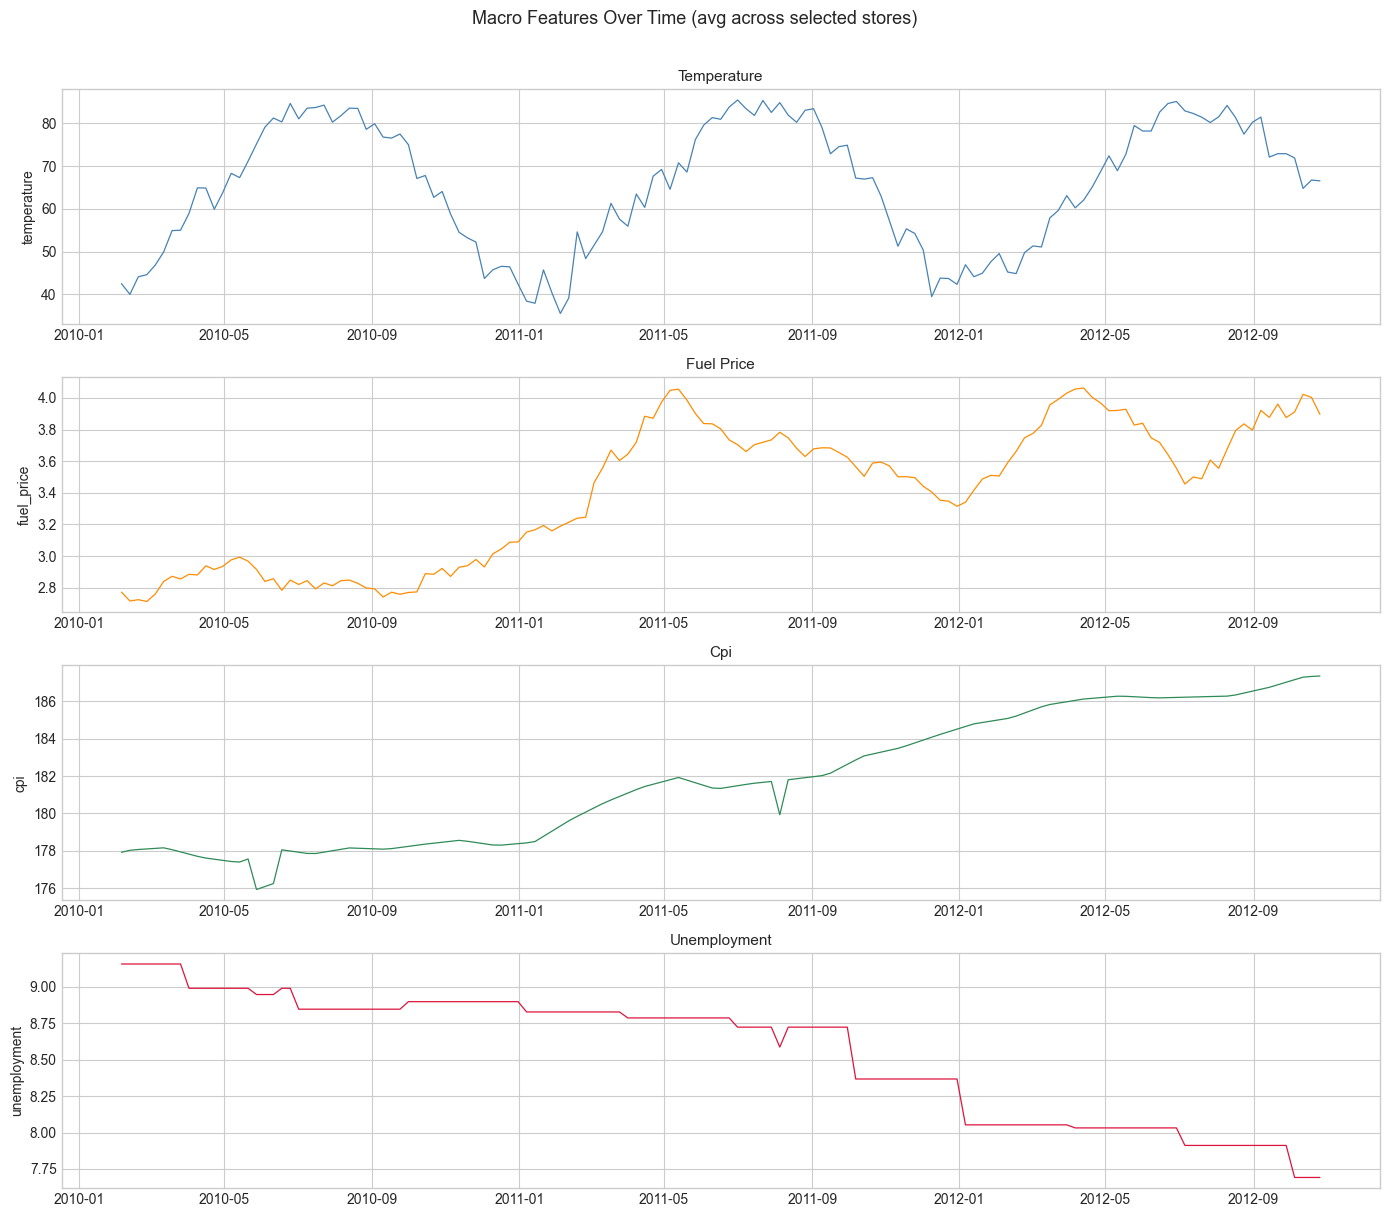

Saved → outputs/03_macro_trends.png


In [27]:
# ── D1: Macro feature trends over time ───────────────────────
macro_cols_present = [c for c in ['temperature','fuel_price','cpi','unemployment']
                      if c in df.columns]

fig, axes = plt.subplots(len(macro_cols_present), 1,
                          figsize=(14, 3*len(macro_cols_present)))

colors = ['steelblue','darkorange','seagreen','crimson']

for i, col in enumerate(macro_cols_present):
    macro_series = df.groupby('date')[col].mean()
    axes[i].plot(macro_series.index, macro_series.values,
                 color=colors[i], linewidth=0.9)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11)
    axes[i].set_ylabel(col)

plt.suptitle('Macro Features Over Time (avg across selected stores)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/03_macro_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/03_macro_trends.png')

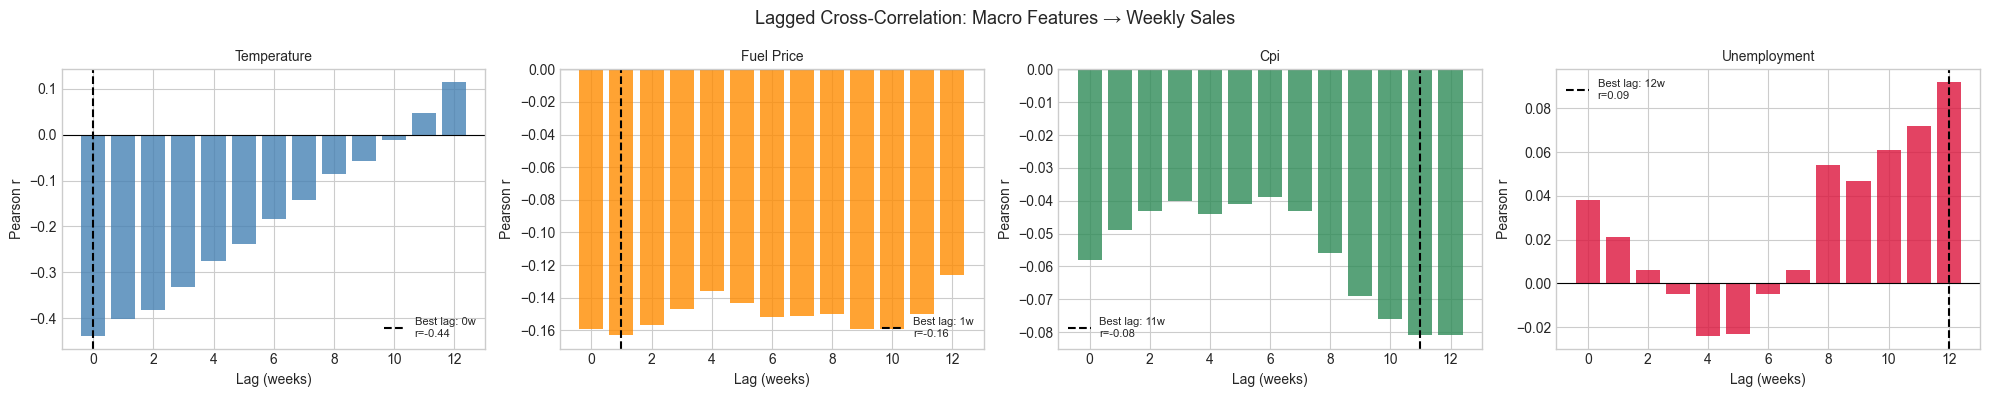


─── CCF Summary (use these lags in ARIMAX) ───
  temperature     → best lag = 0 weeks | r = -0.439
  fuel_price      → best lag = 1 weeks | r = -0.163
  cpi             → best lag = 11 weeks | r = -0.081
  unemployment    → best lag = 12 weeks | r = 0.092

Saved → outputs/04_lagged_ccf.png


In [28]:
# ── D2: Lagged cross-correlation — each macro vs sales ───────
# Key question: does today's unemployment predict sales 1-4 weeks from now?

target = df.groupby('date')['weekly_sales'].sum()

fig, axes = plt.subplots(1, len(macro_cols_present),
                          figsize=(5*len(macro_cols_present), 4))

ccf_summary = {}

for i, col in enumerate(macro_cols_present):
    macro_series = df.groupby('date')[col].mean().reindex(target.index).ffill()

    correlations = {}
    for lag in range(0, 13):
        corr = target.corr(macro_series.shift(lag))
        correlations[lag] = round(corr, 3)

    corr_s = pd.Series(correlations)
    best_lag = corr_s.abs().idxmax()
    ccf_summary[col] = {'best_lag': best_lag, 'corr': corr_s[best_lag]}

    axes[i].bar(corr_s.index, corr_s.values, color=colors[i], alpha=0.8)
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].axvline(best_lag, color='black', linestyle='--',
                    label=f'Best lag: {best_lag}w\nr={corr_s[best_lag]:.2f}')
    axes[i].set_title(col.replace('_',' ').title(), fontsize=10)
    axes[i].set_xlabel('Lag (weeks)')
    axes[i].set_ylabel('Pearson r')
    axes[i].legend(fontsize=8)

plt.suptitle('Lagged Cross-Correlation: Macro Features → Weekly Sales', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/04_lagged_ccf.png', dpi=150)
plt.show()

print('\n─── CCF Summary (use these lags in ARIMAX) ───')
for col, v in ccf_summary.items():
    print(f'  {col:15s} → best lag = {v["best_lag"]} weeks | r = {v["corr"]:.3f}')
print('\nSaved → outputs/04_lagged_ccf.png')

In [29]:
# ── Holiday and Markdown correlation with sales ───────────────

# isholiday — point biserial correlation (binary vs continuous)
from scipy.stats import pointbiserialr

holiday_corr, holiday_p = pointbiserialr(df['isholiday'].astype(int), 
                                          df['weekly_sales'])

# total_markdown — standard Pearson at lag 0
markdown_corr = df['total_markdown'].corr(df['weekly_sales'])

# markdown weeks only — excludes the many zero-markdown weeks
md_nonzero = df[df['total_markdown'] > 0]
markdown_corr_nonzero = md_nonzero['total_markdown'].corr(md_nonzero['weekly_sales'])

print('─── Holiday & Markdown Correlation with Weekly Sales ───')
print(f'isholiday      → r = {holiday_corr:.3f} | p = {holiday_p:.4f}')
print(f'total_markdown → r = {markdown_corr:.3f} (all weeks)')
print(f'total_markdown → r = {markdown_corr_nonzero:.3f} (markdown weeks only)')

─── Holiday & Markdown Correlation with Weekly Sales ───
isholiday      → r = 0.061 | p = 0.0046
total_markdown → r = 0.201 (all weeks)
total_markdown → r = 0.372 (markdown weeks only)


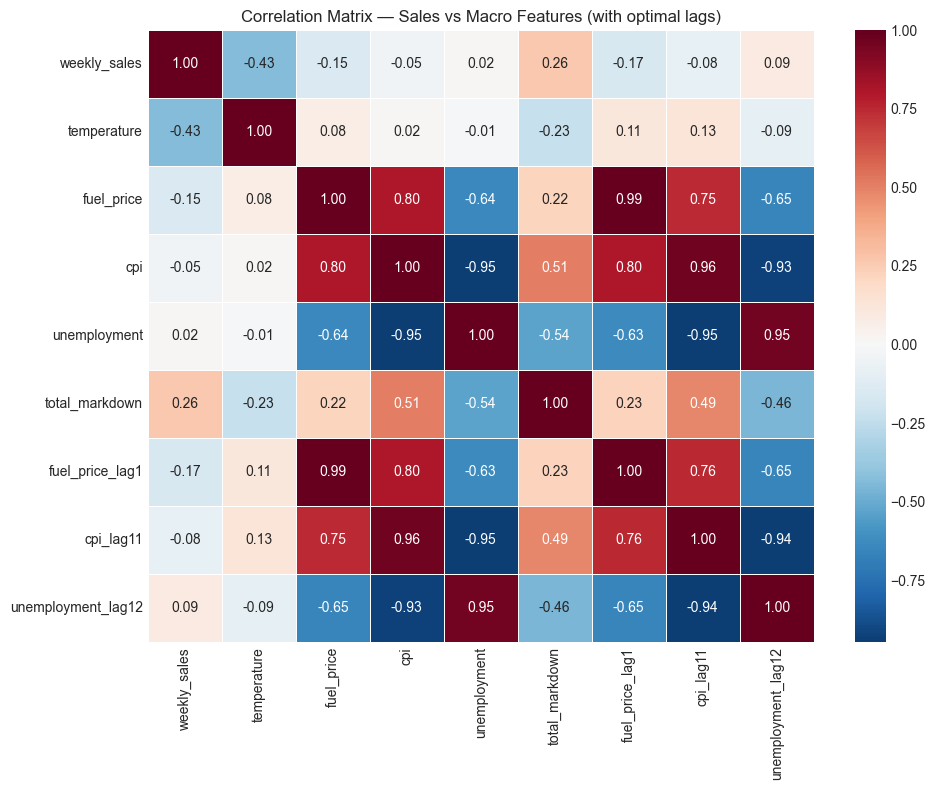

Saved → outputs/05_correlation_heatmap.png


In [30]:
# ── D3: Correlation heatmap — macro features vs sales ────────
corr_df = df.groupby('date').agg(
    weekly_sales  = ('weekly_sales',  'sum'),
    temperature   = ('temperature',   'mean'),
    fuel_price    = ('fuel_price',    'mean'),
    cpi           = ('cpi',           'mean'),
    unemployment  = ('unemployment',  'mean'),
    total_markdown= ('total_markdown','mean')
).dropna()

# Add lagged features based on CCF findings
for col, v in ccf_summary.items():
    lag = v['best_lag']
    if lag > 0:
        corr_df[f'{col}_lag{lag}'] = corr_df[col].shift(lag)

corr_matrix = corr_df.dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Sales vs Macro Features (with optimal lags)',
             fontsize=12)
plt.tight_layout()
plt.savefig('outputs/05_correlation_heatmap.png', dpi=150)
plt.show()
print('Saved → outputs/05_correlation_heatmap.png')

---
## 8. EDA — Section E: Holiday Impact

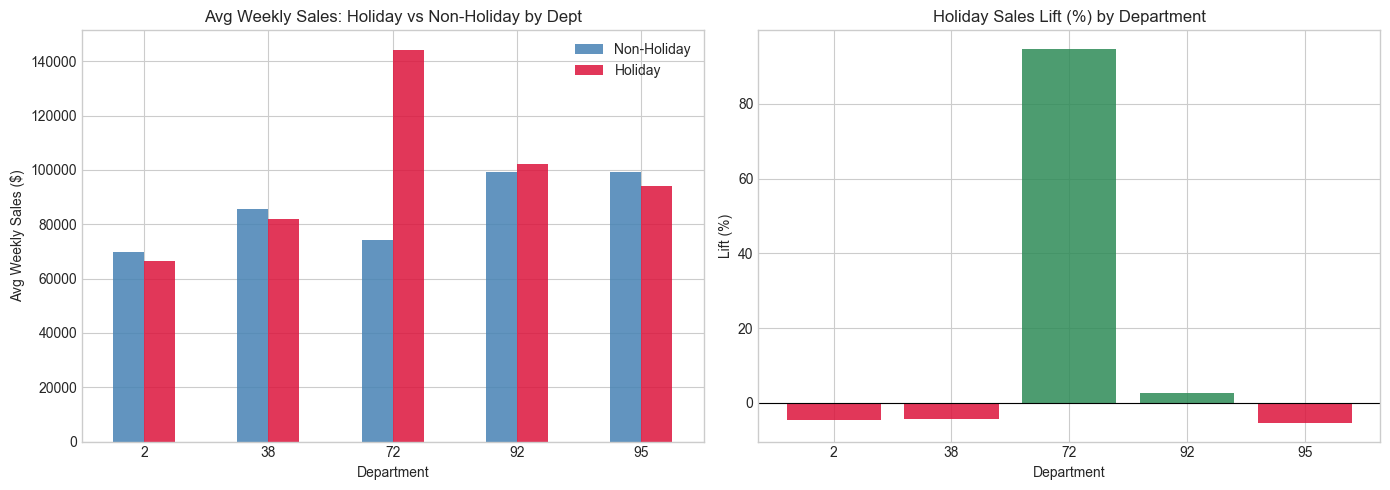


Holiday Lift Table:
      Non-Holiday   Holiday  Lift_%
dept                               
2        69812.51  66627.73   -4.60
38       85559.82  81830.62   -4.40
72       74058.67 144165.11   94.70
92       99391.89 102037.22    2.70
95       99318.88  94004.98   -5.40

Saved → outputs/06_holiday_impact.png


In [31]:
# ── E1: Holiday vs non-holiday avg sales ─────────────────────
holiday_col = 'isholiday' if 'isholiday' in df.columns else 'is_holiday'

holiday_summary = (
    df.groupby([holiday_col, 'dept'])['weekly_sales']
    .mean()
    .unstack(level=0)
)
holiday_summary.columns = ['Non-Holiday', 'Holiday']
holiday_summary['Lift_%'] = (
    (holiday_summary['Holiday'] - holiday_summary['Non-Holiday'])
    / holiday_summary['Non-Holiday'] * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

holiday_summary[['Non-Holiday','Holiday']].plot(
    kind='bar', ax=axes[0], color=['steelblue','crimson'], alpha=0.85)
axes[0].set_title('Avg Weekly Sales: Holiday vs Non-Holiday by Dept', fontsize=12)
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].tick_params(axis='x', rotation=0)

# Lift bar
colors_lift = ['seagreen' if x >= 0 else 'crimson'
               for x in holiday_summary['Lift_%']]
axes[1].bar(holiday_summary.index.astype(str),
            holiday_summary['Lift_%'], color=colors_lift, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Holiday Sales Lift (%) by Department', fontsize=12)
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Lift (%)')

plt.tight_layout()
plt.savefig('outputs/06_holiday_impact.png', dpi=150)
plt.show()

print('\nHoliday Lift Table:')
print(holiday_summary)
print('\nSaved → outputs/06_holiday_impact.png')

---
## 9. EDA — Section F: Markdown Impact

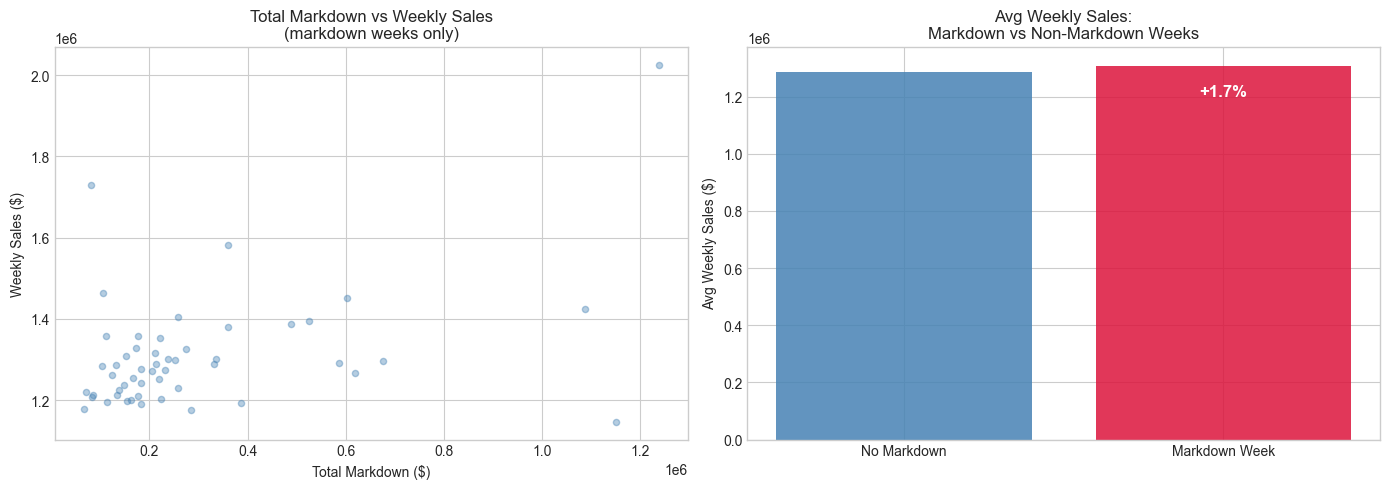

Average sales lift on markdown weeks: 1.7%
Saved → outputs/07_markdown_impact.png


In [32]:
# ── F1: Markdown events vs sales ─────────────────────────────
# Markdowns are Walmart's promotional discounts — anonymized as MD1-MD5
# Key question: do markdown weeks correlate with higher sales?

markdown_analysis = df.groupby('date').agg(
    weekly_sales   = ('weekly_sales',   'sum'),
    total_markdown = ('total_markdown', 'sum')
).reset_index()

# Binary: markdown week or not
markdown_analysis['has_markdown'] = (markdown_analysis['total_markdown'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: markdown value vs sales
md_nonzero = markdown_analysis[markdown_analysis['total_markdown'] > 0]
axes[0].scatter(md_nonzero['total_markdown'], md_nonzero['weekly_sales'],
                alpha=0.4, color='steelblue', s=20)
axes[0].set_title('Total Markdown vs Weekly Sales\n(markdown weeks only)', fontsize=12)
axes[0].set_xlabel('Total Markdown ($)')
axes[0].set_ylabel('Weekly Sales ($)')

# Avg sales: markdown week vs not
md_comparison = markdown_analysis.groupby('has_markdown')['weekly_sales'].mean()
axes[1].bar(['No Markdown','Markdown Week'],
            md_comparison.values, color=['steelblue','crimson'], alpha=0.85)
axes[1].set_title('Avg Weekly Sales:\nMarkdown vs Non-Markdown Weeks', fontsize=12)
axes[1].set_ylabel('Avg Weekly Sales ($)')

md_lift = (md_comparison[1] - md_comparison[0]) / md_comparison[0] * 100
axes[1].text(1, md_comparison[1]*0.95, f'+{md_lift:.1f}%',
             ha='center', va='top', fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('outputs/07_markdown_impact.png', dpi=150)
plt.show()

print(f'Average sales lift on markdown weeks: {md_lift:.1f}%')
print('Saved → outputs/07_markdown_impact.png')

In [34]:
dept_markdown_lift = []

for dept in DEPTS:
    dept_df = df[df['dept'] == dept]
    
    avg_no_md = dept_df[dept_df['total_markdown']==0]['weekly_sales'].mean()
    avg_md    = dept_df[dept_df['total_markdown']>0]['weekly_sales'].mean()
    
    if avg_md > 0 and avg_no_md > 0:
        lift = (avg_md - avg_no_md) / avg_no_md * 100
        n_markdown_weeks = (dept_df['total_markdown'] > 0).sum()
        dept_markdown_lift.append({
            'dept'            : dept,
            'avg_no_markdown' : round(avg_no_md, 0),
            'avg_markdown'    : round(avg_md, 0),
            'lift_%'          : round(lift, 1),
            'markdown_weeks'  : n_markdown_weeks
        })

lift_df = pd.DataFrame(dept_markdown_lift)
print(lift_df.to_string(index=False))

 dept  avg_no_markdown  avg_markdown  lift_%  markdown_weeks
   92         97071.00     104097.00    7.20             153
   95         99899.00      97230.00   -2.70             153
   38         82304.00      90702.00   10.20             153
   72         80969.00      75520.00   -6.70             153
    2         70005.00      68840.00   -1.70             153


In [ ]:
# Verify — markdown values are identical across depts for same store/date
sample = df[df['total_markdown'] > 0].groupby(['store','date'])['total_markdown'].nunique()
print('Unique markdown values per store-date (should all be 1 = store-level, not dept-level):')
print(sample.value_counts())
print(sample.value_counts())
# If all values are 1 → confirmed, markdowns are store-level not dept-level

total_markdown
1    153
Name: count, dtype: int64


---
## 10. Day 1 Summary

In [38]:
# ── Save processed df for Day 2 — no reprocessing needed ─────
df.to_csv('outputs/walmart_processed.csv', index=False)

print('=' * 55)
print('DAY 1 COMPLETE — EDA Summary')
print('=' * 55)
print(f'Date range    : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Stores        : {STORES}  (one per store type A/B/C)')
print(f'Departments   : {DEPTS}  (top 5 by volume)')
print(f'Shape         : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print()
print('─── Key Findings ───')
print()
print('1. SEASONALITY')
print('   All depts show strong annual seasonality (strength 0.818 - 0.971)')
print('   → Justifies SARIMA over plain ARIMA (period=52)')
print('   → Dept 38 lowest at 0.818 — most sensitive to external drivers')
print()
print('2. STATIONARITY')
print('   See stationarity_report.csv for per-dept ADF + KPSS verdicts')
print('   → Non-stationary depts: use d=1 in ARIMA')
print('   → Conflicting results: check ACF/PACF before differencing')
print()
print('3. MACRO REGRESSORS (CCF analysis)')
for col, v in ccf_summary.items():
    decision = 'INCLUDE' if abs(v['corr']) >= 0.15 else 'EXCLUDE — near-zero signal'
    print(f'   {col:15s} → lag {v["best_lag"]:>2} weeks | r={v["corr"]:>7.3f} | {decision}')
print('   Note: CPI and unemployment excluded — Walmart counter-cyclical')
print()
print('4. HOLIDAY IMPACT (per department)')
print('   Dept 72 : +94.7%  → INCLUDE isholiday in ARIMAX')
print('   Dept 92 : +2.7%   → borderline, marginal inclusion')
print('   Dept 2  : -4.6%   → EXCLUDE isholiday (negative lift)')
print('   Dept 38 : -4.4%   → EXCLUDE isholiday (negative lift)')
print('   Dept 95 : -5.4%   → EXCLUDE isholiday (negative lift)')
print('   Note: aggregate isholiday r=0.061 — holiday/non-holiday effects cancel out')
print()
print('5. MARKDOWN IMPACT (per department)')
print('   Dept 38 : +10.2%  → INCLUDE total_markdown in ARIMAX')
print('   Dept 92 : +7.2%   → INCLUDE total_markdown in ARIMAX')
print('   Dept 95 : -2.7%   → EXCLUDE total_markdown')
print('   Dept 2  : -1.7%   → EXCLUDE total_markdown')
print('   Dept 72 : -6.7%   → EXCLUDE (clearance effect, not demand creation)')
print('   Note: all depts had 153 markdown weeks → markdowns are store-level not dept-level')
print()
print('─── ARIMAX Regressor Decisions for Day 3 ───')
print('   temperature    → ALL depts    (lag 0,  r=-0.439)')
print('   fuel_price     → ALL depts    (lag 1,  r=-0.163, borderline)')
print('   isholiday      → Dept 72 only (lag 0,  +94.7% lift)')
print('   total_markdown → Depts 38, 92 (lag 0,  +10.2%, +7.2% lift)')
print('   cpi            → DROPPED      (r=-0.081 at lag 11 — noise)')
print('   unemployment   → DROPPED      (r=+0.092 at lag 12 — noise)')
print()
print('─── Outputs ───')
outputs = [
    '01_sales_overview.png',
    '02_decomposition.png',
    '03_macro_trends.png',
    '04_lagged_ccf.png',
    '05_correlation_heatmap.png',
    '06_holiday_impact.png',
    '07_markdown_impact.png',
    'stationarity_report.csv',
    'walmart_processed.csv      <- load this on Day 2'
]
for o in outputs:
    print(f'  outputs/{o}')

DAY 1 COMPLETE — EDA Summary
Date range    : 2010-02-05 → 2012-10-26
Stores        : [20, 10, 43]  (one per store type A/B/C)
Departments   : [92, 95, 38, 72, 2]  (top 5 by volume)
Shape         : (2141, 12)
Columns       : ['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'type', 'size', 'total_markdown']

─── Key Findings ───

1. SEASONALITY
   All depts show strong annual seasonality (strength 0.818 - 0.971)
   → Justifies SARIMA over plain ARIMA (period=52)
   → Dept 38 lowest at 0.818 — most sensitive to external drivers

2. STATIONARITY
   See stationarity_report.csv for per-dept ADF + KPSS verdicts
   → Non-stationary depts: use d=1 in ARIMA
   → Conflicting results: check ACF/PACF before differencing

3. MACRO REGRESSORS (CCF analysis)
   temperature     → lag  0 weeks | r= -0.439 | INCLUDE
   fuel_price      → lag  1 weeks | r= -0.163 | INCLUDE
   cpi             → lag 11 weeks | r= -0.081 | EXCLUDE — near-zero signal
  

In [39]:
f=pd.read_csv('outputs/walmart_processed.csv')
f.head()

,store,dept,date,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size,total_markdown
0,10,2,2010-02-05,123952.48,False,54.34,2.96,126.44,9.77,B,126512,0.00
1,10,2,2010-02-12,119209.48,True,49.96,2.83,126.50,9.77,B,126512,0.00
2,10,2,2010-02-19,121430.80,False,58.22,2.92,126.53,9.77,B,126512,0.00
3,10,2,2010-02-26,120292.15,False,52.77,2.83,126.55,9.77,B,126512,0.00
4,10,2,2010-03-05,113163.91,False,55.92,2.88,126.58,9.77,B,126512,0.00
